In [14]:
#These are the dataset given to us from kagglehub 
#https://www.kaggle.com/datasets/abhishek14398/heart-disease-classification
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

heart = pd.read_csv("heart.csv")

heart.head()

,age,sex,chest_pain_type,resting_bp,cholestoral,fasting_blood_sugar,restecg,max_hr,exang,oldpeak,slope,num_major_vessels,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
#chest-pain type: 0-typical angina, 1-atypical angina, 2-non-anginal pain, 3-asymptomatic
#restecg (ecg while resting): 0-normal, 1-havting ST-T wave abnormality, 2-showing probably or definte left ventricular hypertrophy
#exang (exercise-induced angina): 1-yes, 0-no
#oldpeak: ST depression induced by exercise relative to rest
#slope: 0-unsloping, 1-flat, 2-downsloping
#thal (thalassemia): 0-normal, 1-fixed defect, 2-reversable defect
#target: 0-no disease, 1-disease

In [4]:
#let's start with KNN

#Here's our variables
x = heart[["age", "sex", "chest_pain_type", "resting_bp", "cholestoral", "fasting_blood_sugar", "restecg", "max_hr", "exang", "oldpeak", "slope", "num_major_vessels", "thal"]]
y = heart["target"]

In [5]:
#Split the data to use for training and testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [11]:
#Scale our model
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [17]:
#Creating KNN
model = KNeighborsClassifier(n_neighbors = 5)

#Fitting our Model
model.fit(x_train_scaled, y_train)

KNeighborsClassifier()

In [24]:
#KNN doesn't have a built in feature importance
#so we're using permutation importance
#Must be used after fitting our model
result = permutation_importance(
    model,
    x_test_scaled,
    y_test,
    random_state=42
)

importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": result.importances_mean
})

importance = importance.sort_values(
    "Importance", ascending=False
)

print(importance)

                Feature  Importance
12                 thal    0.081967
7                max_hr    0.072131
9               oldpeak    0.068852
2       chest_pain_type    0.065574
0                   age    0.065574
1                   sex    0.059016
11    num_major_vessels    0.045902
5   fasting_blood_sugar    0.036066
8                 exang    0.036066
3            resting_bp    0.032787
6               restecg    0.026230
10                slope    0.022951
4           cholestoral    0.019672


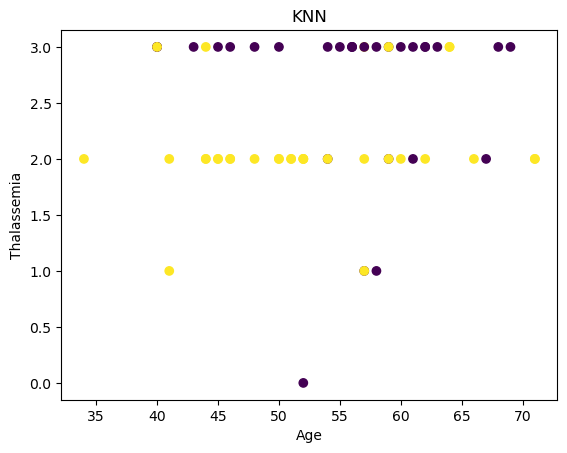

In [28]:
#Best way to visualize KNN is a scatterplot (2 x variables only)
plt.scatter(
    x_test["age"],
    x_test["thal"],
    c = y_test)

plt.xlabel("Age")
plt.ylabel("Thalassemia")
plt.title("KNN")
plt.show()